# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


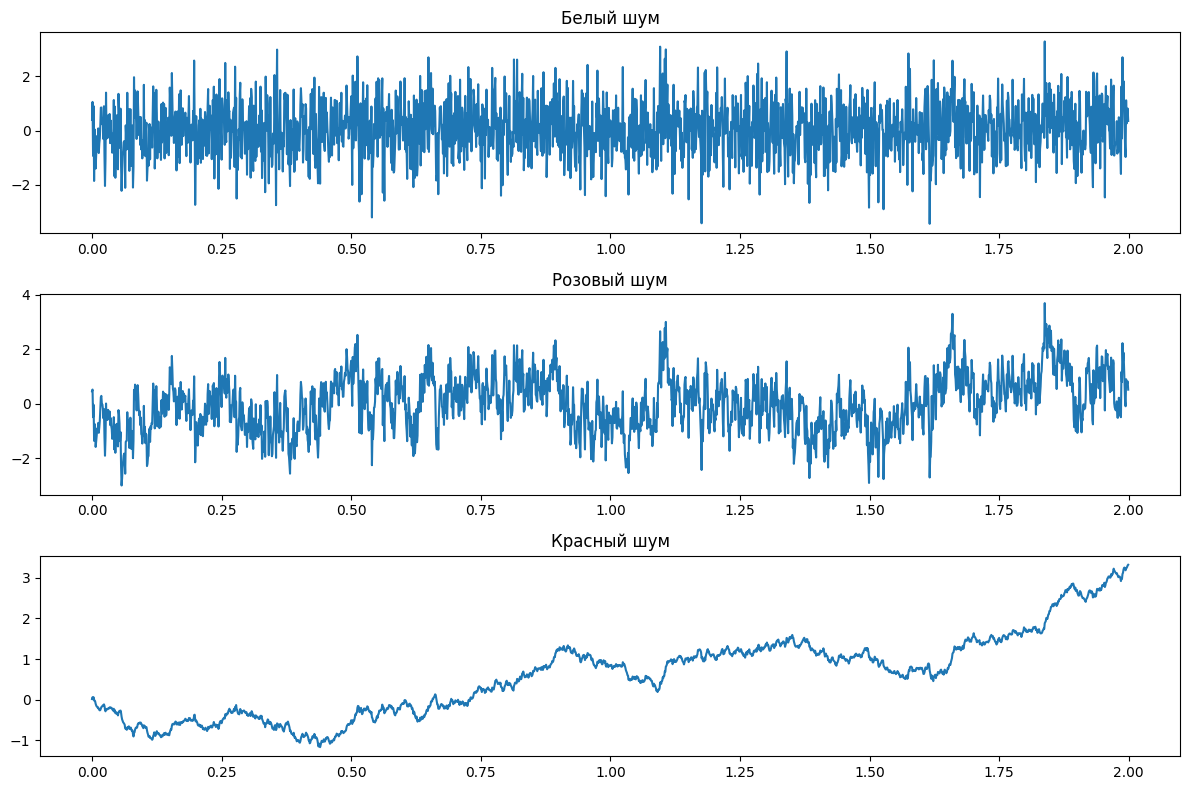

Тип шума        | Среднее    | Дисперсия 
Белый шум       | 0.03891851 | 0.98922817
Розовый шум     | 0.00000000 | 1.00000000
Красный шум     | 0.58788240 | 1.00000000


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

fs = 1000
T = 2000
t = np.arange(T) / fs

white_noise = np.random.normal(0, 1, T)

w_fft = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(T, d=1/fs)

with np.errstate(divide='ignore', invalid='ignore'):
    scaling = 1.0 / np.sqrt(freqs)
scaling[0] = 0

pink_fft = w_fft * scaling
pink_noise = np.fft.irfft(pink_fft, n=T)
pink_noise = pink_noise / np.std(pink_noise)

red_noise = np.cumsum(white_noise)
red_noise = red_noise / np.std(red_noise)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, white_noise)
plt.title('Белый шум')
plt.subplot(3, 1, 2)
plt.plot(t, pink_noise)
plt.title('Розовый шум')
plt.subplot(3, 1, 3)
plt.plot(t, red_noise)
plt.title('Красный шум')
plt.tight_layout()
plt.show()

noises = [white_noise, pink_noise, red_noise]
names = ["Белый шум", "Розовый шум", "Красный шум"]

print(f"{'Тип шума':<15} | {'Среднее':<10} | {'Дисперсия':<10}")

for name, noise in zip(names, noises):
    m = np.mean(noise)
    d = np.var(noise)
    print(f"{name:<15} | {m:<10.8f} | {d:<10.8f}")

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум состоит из постоянных скачков, розовый более мягче по сравнению с белым, а краснай самый плавный, так как каждое следующее значение зависит от предыдущего.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


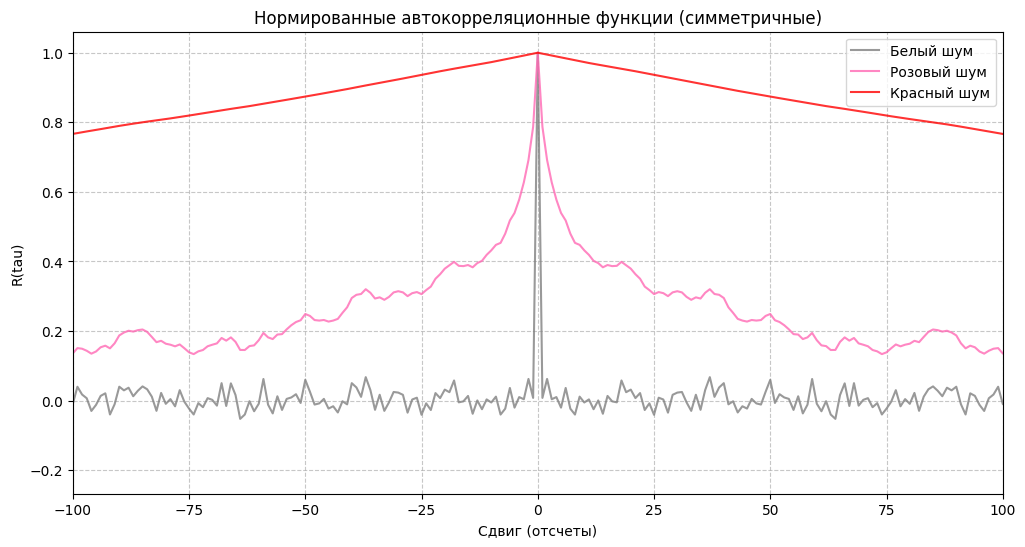

In [29]:
def get_normalized_acf(x):
    corr = np.correlate(x, x, mode='full')
    return corr / np.max(corr)


lags = np.arange(-T + 1, T)

plt.figure(figsize=(12, 6))
plt.plot(lags, get_normalized_acf(white_noise), label='Белый шум', color='gray', alpha=0.8)
plt.plot(lags, get_normalized_acf(pink_noise), label='Розовый шум', color='hotpink', alpha=0.8)
plt.plot(lags, get_normalized_acf(red_noise), label='Красный шум', color='red', alpha=0.8)

plt.title('Нормированные автокорреляционные функции (симметричные)')
plt.xlabel('Сдвиг (отсчеты)')
plt.ylabel('R(tau)')
plt.xlim(-100, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Сравнение показывает связь между шириной основного пика АКФ и коррелированностью сигнала. Белый шум имеет узкий пик в нуле, это означает что отсчеты сигнала не зависят друг от друга. Пик АКФ становится шире, сигнал выглядит плавнее. Красный шум имеет широкую и медленно затухающую АКФ, это указывает на зависимость текущих значений от предыдущих

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


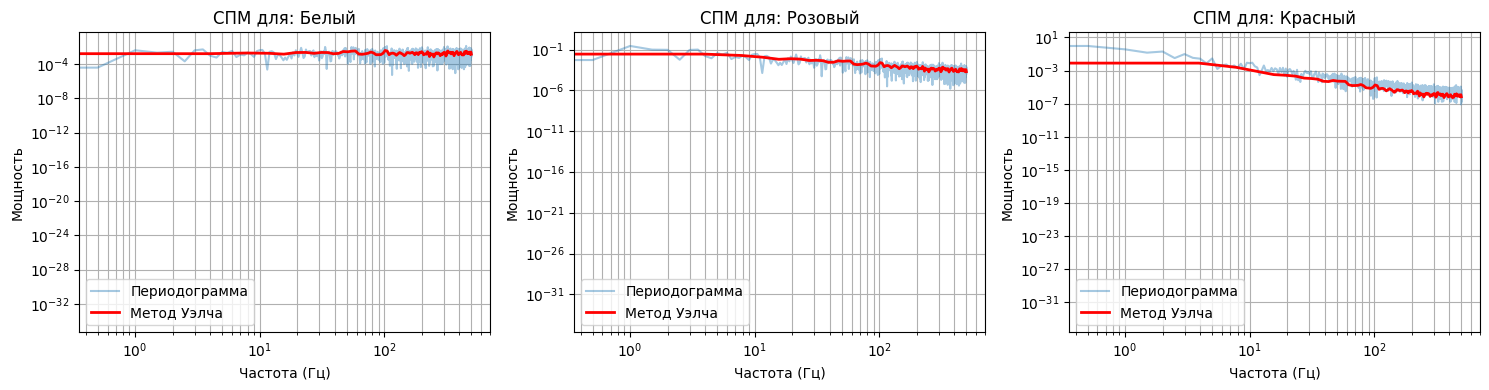

In [30]:
def plot_psd_compare(sig, name):
    f_per, P_per = signal.periodogram(sig, fs)
    f_wel, P_wel = signal.welch(sig, fs, nperseg=256, noverlap=128)

    plt.loglog(f_per, P_per, alpha=0.4, label='Периодограмма')
    plt.loglog(f_wel, P_wel, 'r', linewidth=2, label='Метод Уэлча')
    plt.title(f'СПМ для: {name}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Мощность')
    plt.legend()
    plt.grid(True, which="both")

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plot_psd_compare(white_noise, 'Белый')
plt.subplot(1, 3, 2); plot_psd_compare(pink_noise, 'Розовый')
plt.subplot(1, 3, 3); plot_psd_compare(red_noise, 'Красный')
plt.tight_layout()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


У белого шума прямая горизонтальная линия, теоретически S(f) = const, у розового шума линия равномерно уходит вниз по мере роста частоты, теоретически уравнение прямой с наклоном k = -a, log(S(f)) = log(1) - a*log(f). У красного шума самый крутой наклон, теоритически кручу наклон k

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


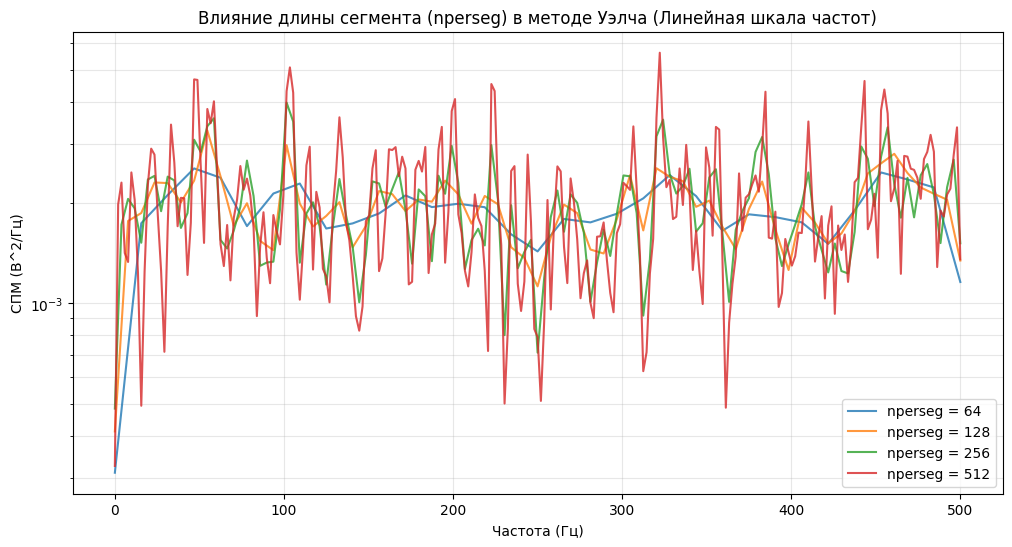

In [42]:
nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(12, 6))

for n in nperseg_values:
    f, Pxx = signal.welch(white_noise, fs, nperseg=n, noverlap=n//2, window='hann')
    plt.semilogy(f, Pxx, label=f'nperseg = {n}', alpha=0.8)

plt.title('Влияние длины сегмента в методе Уэлча (Линейная шкала частот)')
plt.xlabel('Частота (Гц)')
plt.ylabel('СПМ (В^2/Гц)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


С увеличением nperseg пики становятся более узкими, дисперсия растет, а гладкость ухудшается

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

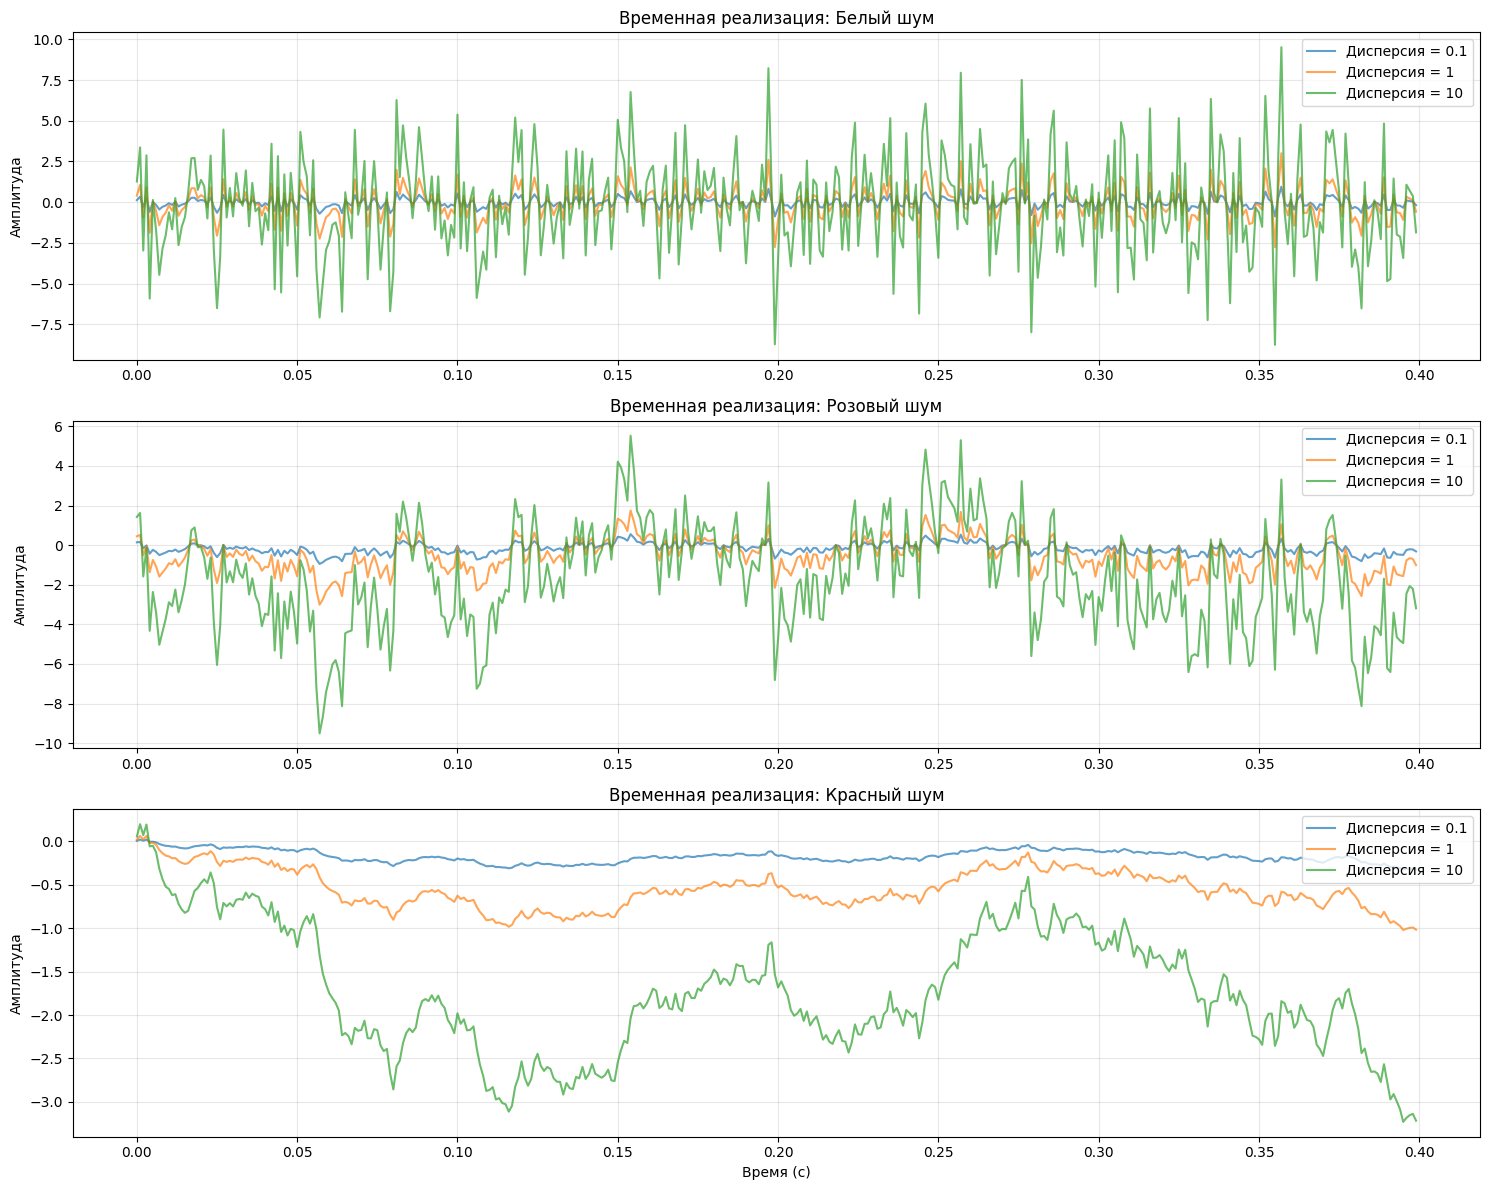

In [50]:
variances = [0.1, 1, 10]
noise_names = ['Белый шум', 'Розовый шум', 'Красный шум']
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(15, 12))

for i, noise in enumerate([white_noise, pink_noise, red_noise]):
    plt.subplot(3, 1, i+1)
    for var in variances:
        scaled_noise = (noise / np.std(noise)) * np.sqrt(var)
        plt.plot(t[:400], scaled_noise[:400], label=f'Дисперсия = {var}', alpha=0.7)

    plt.title(f'Временная реализация: {noise_names[i]}')
    plt.ylabel('Амплитуда')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.xlabel('Время (с)')
plt.tight_layout()
plt.show()

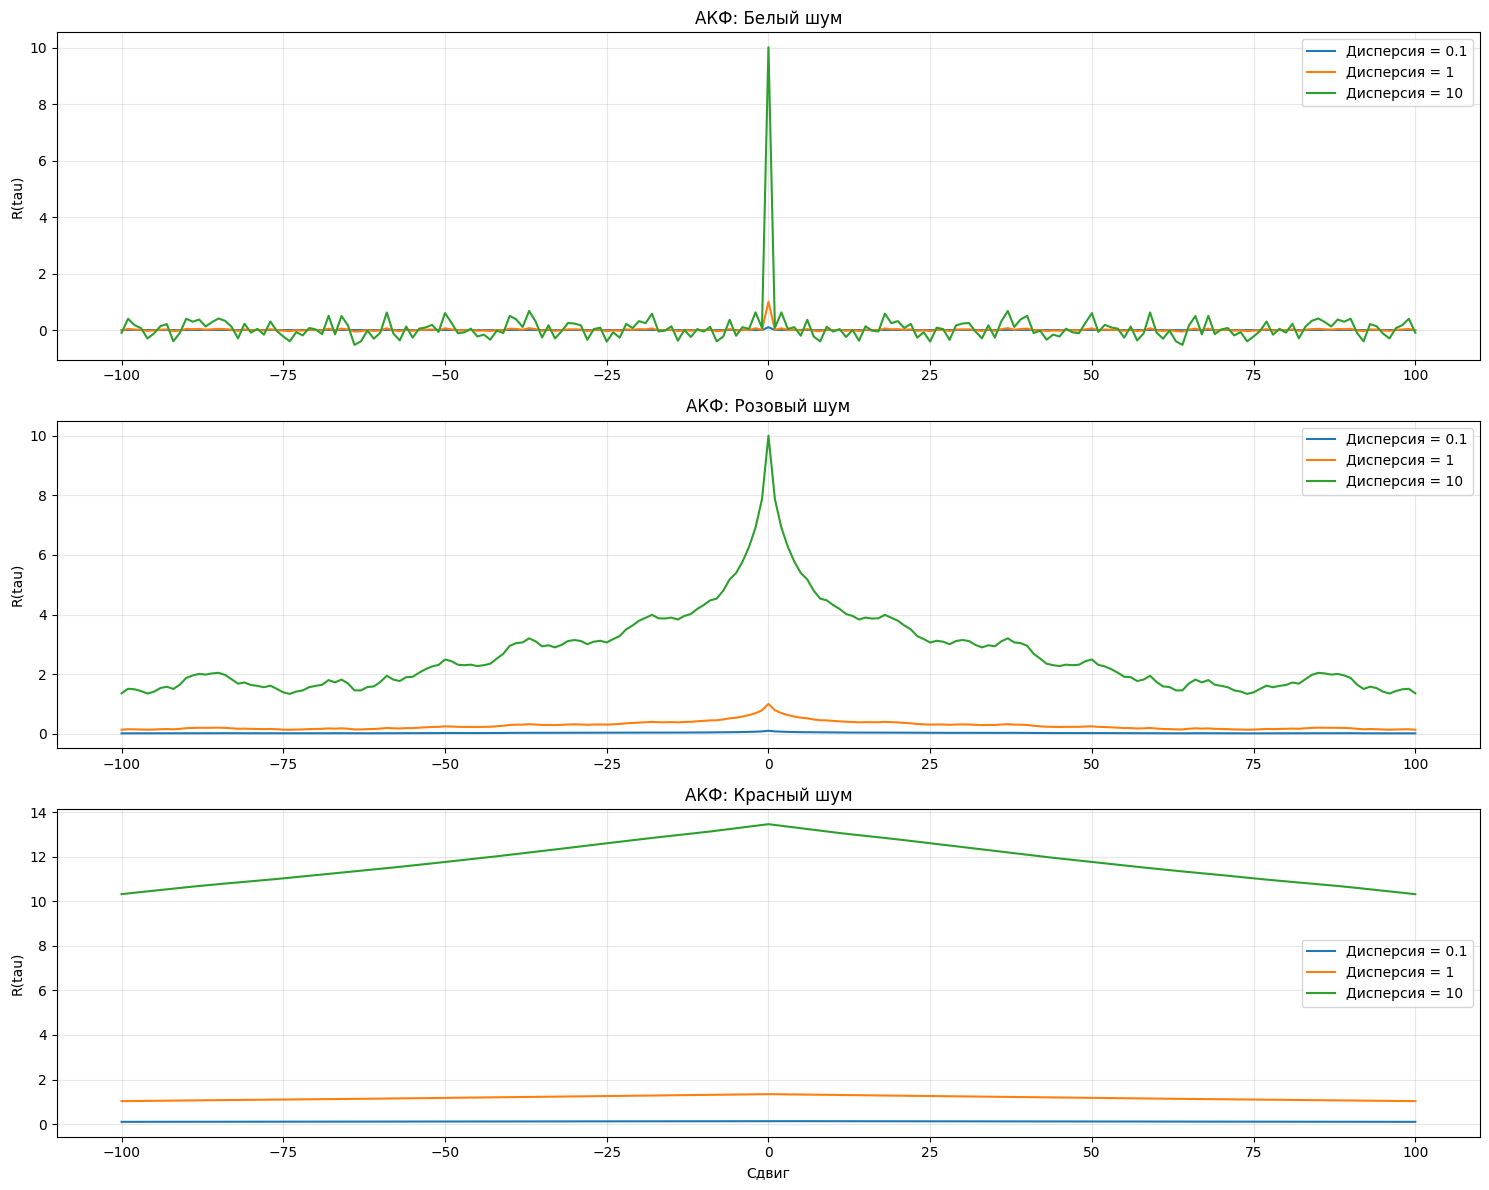

In [51]:
plt.figure(figsize=(15, 12))
k = 100

for i, noise in enumerate([white_noise, pink_noise, red_noise]):
    plt.subplot(3, 1, i+1)
    for var in variances:
        scaled_noise = (noise / np.std(noise)) * np.sqrt(var)

        corr = np.correlate(scaled_noise, scaled_noise, mode='full') / len(scaled_noise)
        lags = np.arange(-len(scaled_noise) + 1, len(scaled_noise))
        mask = (lags >= -k) & (lags <= k)
        plt.plot(lags[mask], corr[mask], label=f'Дисперсия = {var}')

    plt.title(f'АКФ: {noise_names[i]}')
    plt.ylabel('R(tau)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.xlabel('Сдвиг')
plt.tight_layout()
plt.show()

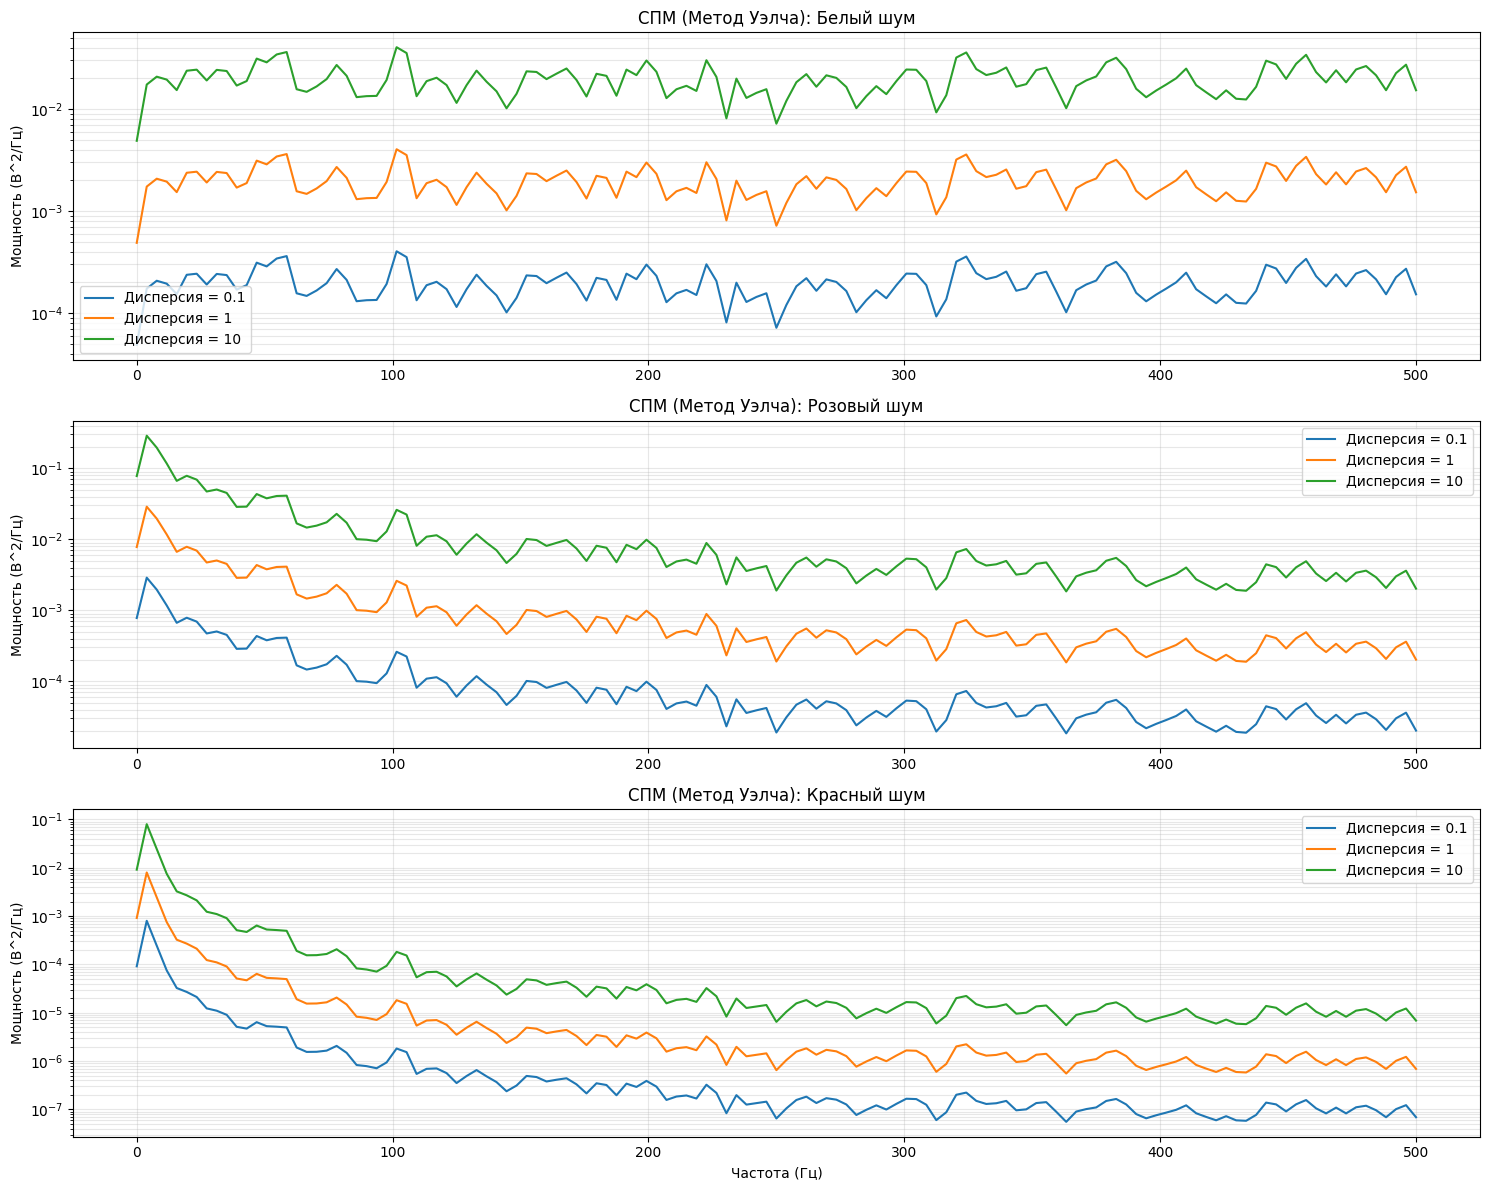

In [48]:
plt.figure(figsize=(15, 12))

for i, noise in enumerate([white_noise, pink_noise, red_noise]):
    plt.subplot(3, 1, i+1)
    for var in variances:
        scaled_noise = (noise / np.std(noise)) * np.sqrt(var)
        f_w, P_w = signal.welch(scaled_noise, fs, nperseg=256)
        plt.semilogy(f_w, P_w, label=f'Дисперсия = {var}')

    plt.title(f'СПМ: {noise_names[i]}')
    plt.ylabel('Мощность (В^2/Гц)')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

plt.xlabel('Частота (Гц)')
plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


Временная область: увеличивается амплитуда сигнала, шум становится высоким

АКФ: значение в нуле увеличивается по значению дисперсии

СПМ: с ростом дисперсии кривая смещается вертикально по оси y

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


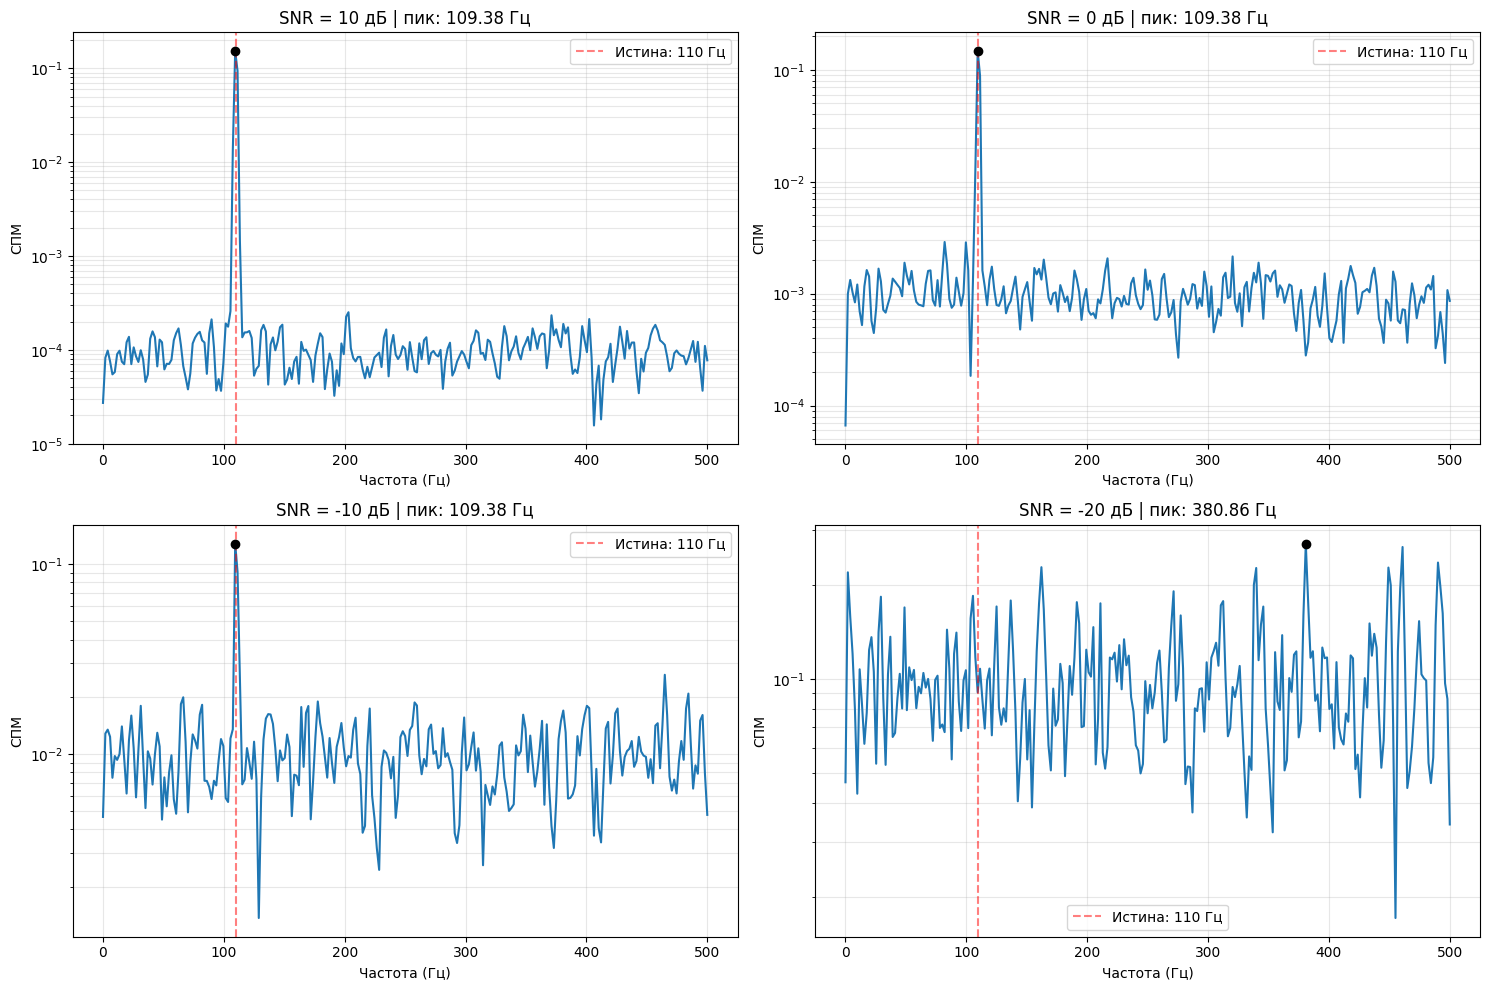

In [53]:
fs1 = 1000
T_total = 2
t = np.arange(int(fs1 * T_total)) / fs1
f0 = 110
A = 1

s_pure = A * np.sin(2 * np.pi * f0 * t)
P_signal = A**2 / 2

snr_values = [10, 0, -10, -20]
nperseg_val = 512

plt.figure(figsize=(15, 10))

for i, snr_db in enumerate(snr_values):
    snr_lin = 10**(snr_db / 10)
    P_noise = P_signal / snr_lin
    noise = np.random.normal(0, np.sqrt(P_noise), len(t))
    s_noisy = s_pure + noise

    f, Pxx = signal.welch(s_noisy, fs1, nperseg=nperseg_val)

    peak_idx = np.argmax(Pxx)
    f_peak = f[peak_idx]

    plt.subplot(2, 2, i+1)
    plt.semilogy(f, Pxx)
    plt.axvline(f0, color='red', linestyle='--', alpha=0.5, label=f'Истина: {f0} Гц')
    plt.scatter(f_peak, Pxx[peak_idx], color='black', zorder=5)

    plt.title(f'SNR = {snr_db} дБ | пик: {f_peak:.2f} Гц')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('СПМ')
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


При уменьшении SNR уровень фонового шума на графике СПМ поднимается выше. При 10 дБ и 0 дБ пик заметно превышает средний уровень шума, При −10 дБ все также выделяется, но не так сильно. При −20 дБ амплитуда полезного сигнала сливается с шумом. Уверенно пик можено обнаружить до SNR ~= -15

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


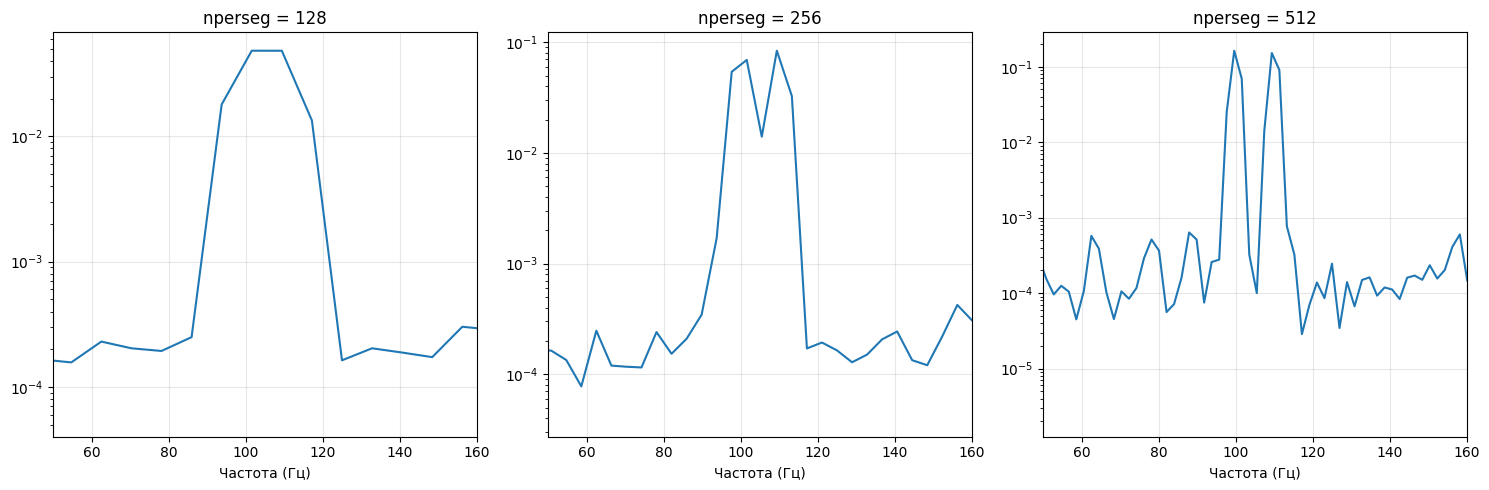

In [57]:
fs2 = 1000
T_res = 1
t_res = np.arange(fs2 * T_res) / fs2

sin_double = np.sin(2 * np.pi * 100 * t_res) + np.sin(2 * np.pi * 110 * t_res)
noise_res = np.random.normal(0, np.sqrt(0.1), len(t_res))
sig_final = sin_double + noise_res

nperseg_res = [128, 256, 512]

plt.figure(figsize=(15, 5))

for i, nper in enumerate(nperseg_res):
    f, Pxx = signal.welch(sig_final, fs2, nperseg=nper)

    plt.subplot(1, 3, i+1)
    plt.semilogy(f, Pxx)
    plt.xlim(50, 160)
    plt.title(f'nperseg = {nper}')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Частота (Гц)')

plt.tight_layout()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


При nperseg = 128 частоты 100 и 110 ГЦ практически неразличимы. При nperseg = 256 можно уже предположить наличие 2 пика. При nperseg = 256 частоты уже четко раличимы


nperseg = 128: 1000/128 = 7.8125 Гц


nperseg = 256: 1000/256 = 3.90625 Гц


nperseg = 256: 1000/256 = 1.953125 Гц